In [1]:
from pre_processing import pre_processing   
from nn import NeuralNet
from sgd import sgd
from plot_metrics import plot_metrics_superimposed

## Train and Eval using SGD, using different learning rate but same batch size

Learning rate: 1.0, batch size: 16 completed.
Train loss: 0.0471, Test loss: 0.2606
Train accuracy: 0.9848, Test accuracy: 0.9444

Learning rate: 0.1, batch size: 16 completed.
Train loss: 0.0762, Test loss: 0.1221
Train accuracy: 0.9781, Test accuracy: 0.9556

Learning rate: 0.01, batch size: 16 completed.
Train loss: 0.4704, Test loss: 0.5035
Train accuracy: 0.8171, Test accuracy: 0.7778



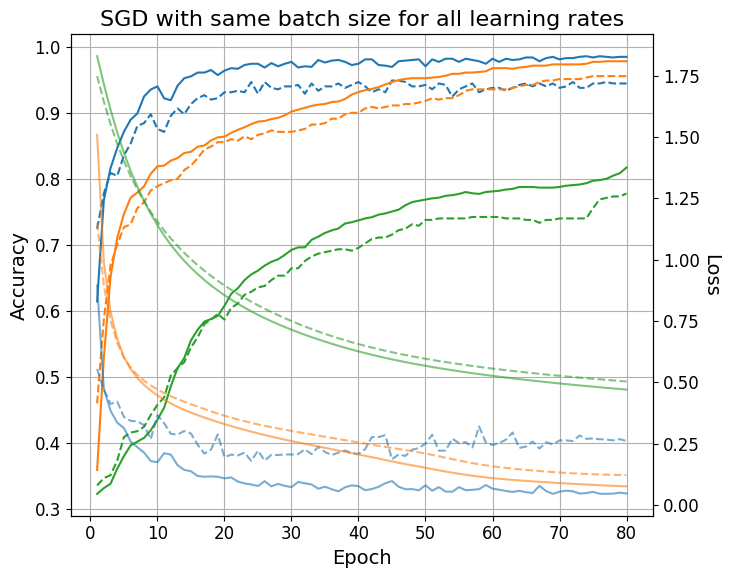

In [ ]:
epochs = 80
seed = 42
layer_sizes = [4, 5, 3, 3]

# Dictionary storing experiemnt_name, metric pairs for plotting
train_loss_dict, test_loss_dict, train_acc_dict, test_acc_dict = {}, {}, {}, {}

# Learning rate, batch size pairs
experiments = {1.0: 16, 0.1: 16, 0.01: 16}

for learning_rate, batch_size in experiments.items():
    
    # For averaging over repeats
    repeat_train_loss, repeat_test_loss, repeat_train_acc, repeat_test_acc = (
        [0 for _ in range(epochs)],
        [0 for _ in range(epochs)],
        [0 for _ in range(epochs)],
        [0 for _ in range(epochs)],
    )

    for repeat in range(10):
        
        # Variation to seed for data shuffling and NN initialization
        repeat_seed = seed + repeat
        training_data, test_data = pre_processing(seed=repeat_seed)
        nn = NeuralNet(seed=repeat_seed, layer_sizes=layer_sizes)

        train_loss, test_loss, train_acc, test_acc = sgd(
            nn=nn,
            training_data=training_data,
            testing_data=test_data,
            epochs=epochs,
            learning_rate=learning_rate,
            batch_size=batch_size,
        )

        # Cumulating metrics over repeats
        repeat_train_loss = [a + b for a, b in zip(repeat_train_loss, train_loss)]
        repeat_test_loss = [a + b for a, b in zip(repeat_test_loss, test_loss)]
        repeat_train_acc = [a + b for a, b in zip(repeat_train_acc, train_acc)]
        repeat_test_acc = [a + b for a, b in zip(repeat_test_acc, test_acc)]

    # Averaging over repeats
    train_loss_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_train_loss]
    test_loss_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_test_loss]
    train_acc_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_train_acc]
    test_acc_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_test_acc]

    print(
        f"Learning rate: {learning_rate}, batch size: {batch_size} completed."
    )
    print(
        f"Train loss: {train_loss_dict[f'lr={learning_rate}'][-1]:.4f}, Test loss: {test_loss_dict[f'lr={learning_rate}'][-1]:.4f}"
    )
    print(
        f"Train accuracy: {train_acc_dict[f'lr={learning_rate}'][-1]:.4f}, Test accuracy: {test_acc_dict[f'lr={learning_rate}'][-1]:.4f}\n"
    )
    
plot_metrics_superimposed(
    title= 'SGD with same batch size for all learning rates',
    train_loss=train_loss_dict,
    test_loss=test_loss_dict,
    train_acc=train_acc_dict,
    test_acc=test_acc_dict,
    show_legend = True
)

## We repeat the experiment but with batch sizes increasing proportionally to learning rate

Learning rate: 1.0, batch size: 160 completed.
Train loss: 0.0786, Test loss: 0.1214
Train accuracy: 0.9724, Test accuracy: 0.9578

Learning rate: 0.1, batch size: 16 completed.
Train loss: 0.0762, Test loss: 0.1221
Train accuracy: 0.9781, Test accuracy: 0.9556

Learning rate: 0.01, batch size: 2 completed.
Train loss: 0.1071, Test loss: 0.1588
Train accuracy: 0.9695, Test accuracy: 0.9333



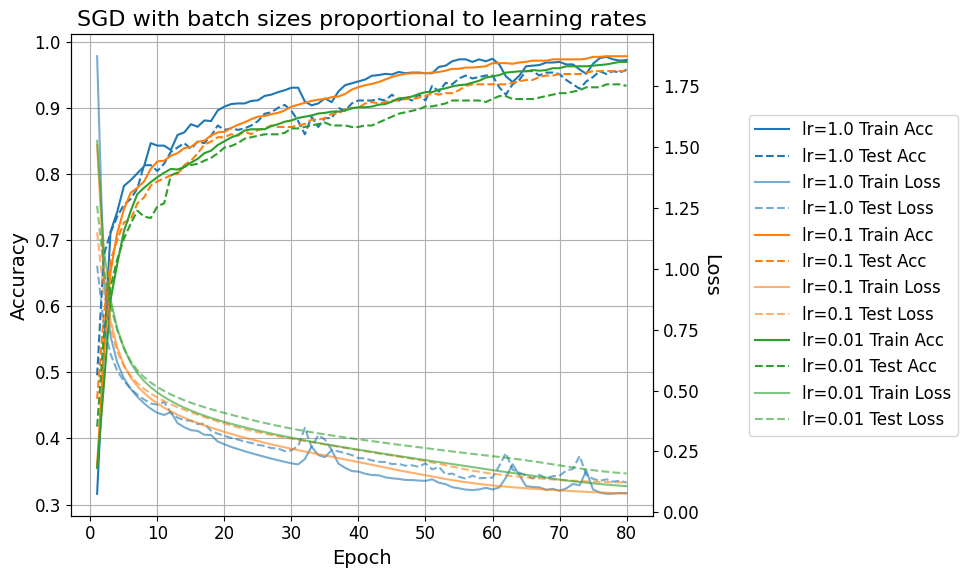

In [3]:
epochs = 80
seed = 42
layer_sizes = [4, 5, 3, 3]

# Dictionary storing experiemnt_name, metric pairs for plotting
train_loss_dict, test_loss_dict, train_acc_dict, test_acc_dict = {}, {}, {}, {}

# Learning rate, batch size pairs
experiments = {1.0: 160, 0.1: 16, 0.01: 2}

for learning_rate, batch_size in experiments.items():
    
    # For averaging over repeats
    repeat_train_loss, repeat_test_loss, repeat_train_acc, repeat_test_acc = (
        [0 for _ in range(epochs)],
        [0 for _ in range(epochs)],
        [0 for _ in range(epochs)],
        [0 for _ in range(epochs)],
    )

    for repeat in range(10):
        
        # Variation to seed for data shuffling and NN initialization
        repeat_seed = seed + repeat
        training_data, test_data = pre_processing(seed=repeat_seed)
        nn = NeuralNet(seed=repeat_seed, layer_sizes=layer_sizes)

        train_loss, test_loss, train_acc, test_acc = sgd(
            nn=nn,
            training_data=training_data,
            testing_data=test_data,
            epochs=epochs,
            learning_rate=learning_rate,
            batch_size=batch_size,
        )

        # Cumulating metrics over repeats
        repeat_train_loss = [a + b for a, b in zip(repeat_train_loss, train_loss)]
        repeat_test_loss = [a + b for a, b in zip(repeat_test_loss, test_loss)]
        repeat_train_acc = [a + b for a, b in zip(repeat_train_acc, train_acc)]
        repeat_test_acc = [a + b for a, b in zip(repeat_test_acc, test_acc)]

    # Averaging over repeats
    train_loss_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_train_loss]
    test_loss_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_test_loss]
    train_acc_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_train_acc]
    test_acc_dict[f"lr={learning_rate}"] = [a / 10 for a in repeat_test_acc]

    print(
        f"Learning rate: {learning_rate}, batch size: {batch_size} completed."
    )
    print(
        f"Train loss: {train_loss_dict[f'lr={learning_rate}'][-1]:.4f}, Test loss: {test_loss_dict[f'lr={learning_rate}'][-1]:.4f}"
    )
    print(
        f"Train accuracy: {train_acc_dict[f'lr={learning_rate}'][-1]:.4f}, Test accuracy: {test_acc_dict[f'lr={learning_rate}'][-1]:.4f}\n"
    )
    
plot_metrics_superimposed(
    title= 'SGD with batch sizes proportional to learning rates',
    train_loss=train_loss_dict,
    test_loss=test_loss_dict,
    train_acc=train_acc_dict,
    test_acc=test_acc_dict,
    show_legend = True
)